##### Classical SVM Implementation - Spambase - PCA

In [35]:
# =============================================================================
# SECTION 1: IMPORTS
# =============================================================================
# --- Import Libraries ---
import pandas as pd
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, accuracy_score, 
                             confusion_matrix, precision_score, 
                             recall_score, f1_score, balanced_accuracy_score)
from sklearn.feature_selection import VarianceThreshold

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [36]:
# --- Import Spambase Column Names ---
spambase_columns = [
    "word_freq_make",
    "word_freq_address",
    "word_freq_all",
    "word_freq_3d",
    "word_freq_our",
    "word_freq_over",
    "word_freq_remove",
    "word_freq_internet",
    "word_freq_order",
    "word_freq_mail",
    "word_freq_receive",
    "word_freq_will",
    "word_freq_people",
    "word_freq_report",
    "word_freq_addresses",
    "word_freq_free",
    "word_freq_business",
    "word_freq_email",
    "word_freq_you",
    "word_freq_credit",
    "word_freq_your",
    "word_freq_font",
    "word_freq_000",
    "word_freq_money",
    "word_freq_hp",
    "word_freq_hpl",
    "word_freq_george",
    "word_freq_650",
    "word_freq_lab",
    "word_freq_labs",
    "word_freq_telnet",
    "word_freq_857",
    "word_freq_data",
    "word_freq_415",
    "word_freq_85",
    "word_freq_technology",
    "word_freq_1999",
    "word_freq_parts",
    "word_freq_pm",
    "word_freq_direct",
    "word_freq_cs",
    "word_freq_meeting",
    "word_freq_original",
    "word_freq_project",
    "word_freq_re",
    "word_freq_edu",
    "word_freq_table",
    "word_freq_conference",
    "char_freq_;",
    "char_freq_(",
    "char_freq_[",
    "char_freq_!",
    "char_freq_$",
    "char_freq_#",
    "capital_run_length_average",
    "capital_run_length_longest",
    "capital_run_length_total",
    # finally the target label column:
    "label"
]

# Load data
file_path = r'C:\Users\User\Documents\MyProjects\FYP_ResearchProject\data\spambase\spambase.data'
df = pd.read_csv(file_path, header=None, names=spambase_columns)

# Drop duplicates
print(f"Original shape of Spambase data: {df.shape}") # Prints original dataset shape
df.drop_duplicates(inplace=True) # Remove duplicates
print(f"Shape after dropping duplicates: {df.shape}\n") # Then print again the new shape

Original shape of Spambase data: (4601, 58)
Shape after dropping duplicates: (4210, 58)



In [37]:
# ================================================================================
# CELL 3: Experiment Configurations (FULL COMBINATORIAL GRID)
# ================================================================================


# ==========================================
# EXPERIMENT CONFIGURATIONS
# ==========================================


# Define parameter ranges
sample_sizes = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
n_components_range = [2, 3, 4, 5, 6, 7, 8]  # PCA components to test
kernels = ['linear', 'rbf']


# Generate all combinations programmatically
experiments = []
exp_id = 1


for samples in sample_sizes:
    for n_comp in n_components_range:  
        for kernel in kernels:
            experiments.append({
                'id': f'Exp{exp_id:03d}_{samples}samp_{n_comp}comp_{kernel}',
                'samples': samples,
                'n_components': n_comp,
                'kernel': kernel
            })
            exp_id += 1


print(f"Total experiments configured: {len(experiments)}")
print(f"Parameter Grid:")
print(f"  - Sample Sizes: {sample_sizes}")
print(f"  - PCA Components: {n_components_range}")  
print(f"  - Kernels: {kernels}")
print(f"  - Total Combinations: {len(sample_sizes)} × {len(n_components_range)} × {len(kernels)} = {len(experiments)}")  
print(f"\n Warning: This will take a LONG time to run!")
print(f"   Estimated time: ~{len(experiments) * 0.1:.0f} minutes\n")

print("Preview of first 5 experiments:")
for exp in experiments[:5]:
    print(f"  {exp['id']}: samples={exp['samples']}, n_components={exp['n_components']}, kernel={exp['kernel']}")

Total experiments configured: 140
Parameter Grid:
  - Sample Sizes: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
  - PCA Components: [2, 3, 4, 5, 6, 7, 8]
  - Kernels: ['linear', 'rbf']
  - Total Combinations: 10 × 7 × 2 = 140

   Estimated time: ~14 minutes

Preview of first 5 experiments:
  Exp001_100samp_2comp_linear: samples=100, n_components=2, kernel=linear
  Exp002_100samp_2comp_rbf: samples=100, n_components=2, kernel=rbf
  Exp003_100samp_3comp_linear: samples=100, n_components=3, kernel=linear
  Exp004_100samp_3comp_rbf: samples=100, n_components=3, kernel=rbf
  Exp005_100samp_4comp_linear: samples=100, n_components=4, kernel=linear


##### Main Experiment Loop

In [38]:
# ================================================================================
# MAIN EXPERIMENT LOOP
# ================================================================================

# Store all results
all_results = []

for i, exp in enumerate(experiments):
    print(f"\n{'='*80}")
    print(f"EXPERIMENT {i+1}/{len(experiments)}: {exp['id']}")
    print(f"{'='*80}")
    print(f" Samples: {exp['samples']}")
    print(f" PCA Components: {exp['n_components']}")
    print(f"{'='*80}")
    
    # -----------------------------------
    # 1. Stratified Sub-sampling
    # -----------------------------------
    X = df.drop('label', axis=1)
    y = df['label']
    
    # Calculate what fraction we need to get desired sample count for training
    total_samples_needed = int(exp['samples'] / 0.7)  # 70% train, 30% test
    if total_samples_needed > len(df):
        total_samples_needed = len(df)
    sample_fraction = total_samples_needed / len(df)
    
    # First, get the subset we'll work with
    if sample_fraction < 1.0:
        X_sample, _, y_sample, _ = train_test_split(
            X, y,
            test_size=(1 - sample_fraction),
            stratify=y,
            random_state=42
        )
    else:
        X_sample, y_sample = X, y
    
    # Split into train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X_sample, y_sample,
        test_size=0.30,
        random_state=42,
        stratify=y_sample
    )
    
    # Truncate to exact sample size if needed
    if len(X_train) > exp['samples']:
        X_train = X_train.iloc[:exp['samples']]
        y_train = y_train.iloc[:exp['samples']]
    
    print(f"\nDataset created: {len(X_train)} train, {len(X_test)} test")
    
    # -----------------------------------
    # 2. Scaling
    # -----------------------------------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Convert back to DataFrames to retain column names for the next step
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)
    
    print("Data scaled successfully")
    
    # -----------------------------------
    # 3. Feature Selection (Correlation-based removal)
    # -----------------------------------
    THRESH = 0.9
    corr_matrix_train = X_train_scaled_df.corr().abs()
    upper_triangle = corr_matrix_train.where(np.triu(np.ones(corr_matrix_train.shape), k=1).astype(bool))
    
    columns_to_drop = set()
    for column in upper_triangle.columns:
        high_corr_partners = upper_triangle.index[upper_triangle[column] > THRESH].tolist()
        if high_corr_partners:
            for partner in high_corr_partners:
                corr_main_vs_target = pd.Series(y_train.values).corr(X_train_scaled_df[column])
                corr_partner_vs_target = pd.Series(y_train.values).corr(X_train_scaled_df[partner])
                
                if abs(corr_main_vs_target) < abs(corr_partner_vs_target):
                    columns_to_drop.add(column)
                else:
                    columns_to_drop.add(partner)
    
    to_drop_final = sorted(list(columns_to_drop))
    X_train_selected = X_train_scaled_df.drop(columns=to_drop_final)
    X_test_selected = X_test_scaled_df.drop(columns=to_drop_final)
    
    print(f"Dropped {len(to_drop_final)} highly correlated features")
    
    # -----------------------------------
    # 4. PCA Dimensionality Reduction
    # -----------------------------------
    n_comp = exp['n_components']
    
    # Ensure we don't request more components than available features
    max_components = min(n_comp, X_train_selected.shape[1], X_train_selected.shape[0])
    
    pca = PCA(n_components=max_components, random_state=42)
    X_train_pca = pca.fit_transform(X_train_selected)
    X_test_pca = pca.transform(X_test_selected)
    
    explained_variance = sum(pca.explained_variance_ratio_) * 100
    print(f"PCA: Reduced to {max_components} components (Explained variance: {explained_variance:.2f}%)")
    
    # -----------------------------------
    # 5. Grid Search for Hyperparameters
    # -----------------------------------
    kernel = exp['kernel']
    
    if kernel == 'linear':
        print(f"\nGrid searching for optimal hyperparameters (Kernel: LINEAR)...")
        param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
        grid_model = SVC(kernel='linear', random_state=42)
    else:  # RBF
        print(f"\nGrid searching for optimal hyperparameters (Kernel: RBF)...")
        param_grid = {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 1, 0.1, 0.01, 0.001]
        }
        grid_model = SVC(kernel='rbf', random_state=42)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    start_time = time.time()
    
    grid_search = GridSearchCV(
        grid_model,
        param_grid,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    grid_search.fit(X_train_pca, y_train)
    
    training_time = time.time() - start_time
    
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    cv_score = grid_search.best_score_
    
    print(f" → Best C: {best_params['C']}")
    if kernel == 'rbf':
        print(f" → Best Gamma: {best_params['gamma']}")
    print(f" → CV Score: {cv_score:.4f}")
    print(f" → Training time: {training_time:.2f}s")
    
    # -----------------------------------
    # 6. Model Evaluation
    # -----------------------------------
    y_train_pred = best_model.predict(X_train_pca)
    y_test_pred = best_model.predict(X_test_pca)
    
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_balanced_acc = balanced_accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    gen_gap = abs(train_accuracy - test_accuracy)
    
    print(f"\n --- Model Performance ---")
    print(f" → Train Accuracy: {train_accuracy:.4f}")
    print(f" → Test Accuracy: {test_accuracy:.4f}")
    print(f" → Test Balanced Accuracy: {test_balanced_acc:.4f}")
    print(f" → Precision: {precision:.4f}")
    print(f" → Recall: {recall:.4f}")
    print(f" → F1-Score: {f1:.4f}")
    print(f" → Generalization Gap: {gen_gap:.4f}")
    
    print(f"\n --- Classification Report ---")
    print(classification_report(y_test, y_test_pred, target_names=['Non-Spam', 'Spam']))
    
    # -----------------------------------
    # 7. Store Results
    # -----------------------------------
    result = {
        'experiment_id': exp['id'],
        'samples': exp['samples'],
        'n_components': max_components,
        'kernel': kernel,
        'best_C': best_params['C'],
        'best_gamma': best_params.get('gamma', 'N/A'),
        'cv_score': cv_score,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'test_balanced_accuracy': test_balanced_acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'generalization_gap': gen_gap,
        'explained_variance_ratio': explained_variance,
        'training_time': training_time
    }
    all_results.append(result)

print(f"\n{'='*80}")
print("ALL EXPERIMENTS COMPLETED!")
print(f"{'='*80}")


EXPERIMENT 1/140: Exp001_100samp_2comp_linear
 Samples: 100
 PCA Components: 2

Dataset created: 99 train, 43 test
Data scaled successfully
Dropped 5 highly correlated features
PCA: Reduced to 2 components (Explained variance: 18.82%)

Grid searching for optimal hyperparameters (Kernel: LINEAR)...
 → Best C: 0.1
 → CV Score: 0.9489
 → Training time: 0.57s

 --- Model Performance ---
 → Train Accuracy: 0.9394
 → Test Accuracy: 0.8605
 → Test Balanced Accuracy: 0.8541
 → Precision: 0.8235
 → Recall: 0.8235
 → F1-Score: 0.8235
 → Generalization Gap: 0.0789

 --- Classification Report ---
              precision    recall  f1-score   support

    Non-Spam       0.88      0.88      0.88        26
        Spam       0.82      0.82      0.82        17

    accuracy                           0.86        43
   macro avg       0.85      0.85      0.85        43
weighted avg       0.86      0.86      0.86        43


EXPERIMENT 2/140: Exp002_100samp_2comp_rbf
 Samples: 100
 PCA Components: 2

Da

##### Save Results to CSV

In [39]:
# Save results to CSV
results_df = pd.DataFrame(all_results)
results_df.to_csv('classical_svm_pca_results_v2.csv', index=False)
print(f"Results saved to classical_svm_pca_results_v2.csv")
print(f"\nResults Summary:")
print(results_df.to_string())

Results saved to classical_svm_pca_results_v2.csv

Results Summary:
                    experiment_id  samples  n_components  kernel  best_C best_gamma  cv_score  train_accuracy  test_accuracy  test_balanced_accuracy  precision    recall  f1_score  generalization_gap  explained_variance_ratio  training_time
0     Exp001_100samp_2comp_linear      100             2  linear    0.10        N/A  0.948947        0.939394       0.860465                0.854072   0.823529  0.823529  0.823529            0.078929                 18.823437       0.568931
1        Exp002_100samp_2comp_rbf      100             2     rbf    1.00       auto  0.948947        0.939394       0.837209                0.824661   0.812500  0.764706  0.787879            0.102185                 18.823437       0.178044
2     Exp003_100samp_3comp_linear      100             3  linear    0.10        N/A  0.938947        0.949495       0.860465                0.854072   0.823529  0.823529  0.823529            0.089030          

##### Results Analysis

In [40]:
# Basic Analysis
print("=" * 60)
print("RESULTS ANALYSIS")
print("=" * 60)

# Best overall model
best_idx = results_df['test_accuracy'].idxmax()
best_result = results_df.loc[best_idx]
print(f"\n--- Best Overall Model ---")
print(f"Experiment: {best_result['experiment_id']}")
print(f"Test Accuracy: {best_result['test_accuracy']:.4f}")
print(f"Samples: {best_result['samples']}")
print(f"PCA Components: {best_result['n_components']}")
print(f"Kernel: {best_result['kernel']}")
print(f"Best C: {best_result['best_C']}")
if best_result['kernel'] == 'rbf':
    print(f"Best Gamma: {best_result['best_gamma']}")

# Best by kernel type
print(f"\n--- Best by Kernel Type ---")
for kernel in ['linear', 'rbf']:
    kernel_results = results_df[results_df['kernel'] == kernel]
    if len(kernel_results) > 0:
        best_kernel_idx = kernel_results['test_accuracy'].idxmax()
        best_kernel = kernel_results.loc[best_kernel_idx]
        print(f"\n{kernel.upper()}:")
        print(f"  Best Test Accuracy: {best_kernel['test_accuracy']:.4f}")
        print(f"  Samples: {best_kernel['samples']}, Components: {best_kernel['n_components']}")
        print(f"  Gen Gap: {best_kernel['generalization_gap']:.4f}")

# Statistics by PCA components
print(f"\n--- Average Performance by PCA Components ---")
comp_stats = results_df.groupby('n_components').agg({
    'test_accuracy': ['mean', 'std'],
    'generalization_gap': 'mean',
    'explained_variance_ratio': 'mean'
}).round(4)
print(comp_stats)

RESULTS ANALYSIS

--- Best Overall Model ---
Experiment: Exp096_700samp_7comp_rbf
Test Accuracy: 0.9233
Samples: 700
PCA Components: 7
Kernel: rbf
Best C: 100.0
Best Gamma: 0.001

--- Best by Kernel Type ---

LINEAR:
  Best Test Accuracy: 0.9167
  Samples: 700, Components: 6
  Gen Gap: 0.0138

RBF:
  Best Test Accuracy: 0.9233
  Samples: 700, Components: 7
  Gen Gap: 0.0176

--- Average Performance by PCA Components ---
             test_accuracy         generalization_gap explained_variance_ratio
                      mean     std               mean                     mean
n_components                                                                  
2                   0.8720  0.0174             0.0259                  16.3753
3                   0.8733  0.0211             0.0279                  20.8865
4                   0.8750  0.0211             0.0297                  24.5430
5                   0.8811  0.0223             0.0264                  27.8362
6                   0.8

### Visualization and Full Dataset Experiments

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 8

def plot_classical_svm_analysis(df):
    """
    Generates standardized visualizations for Classical SVM experiments (PCA version).
    Compares RBF vs Linear kernels across different configurations.
    """
    
    print("\n" + "="*80)
    print("CLASSICAL SVM PERFORMANCE ANALYSIS (PCA)")
    print("="*80)
    
    # Separate by kernel
    rbf_df = df[df['kernel'] == 'rbf'].copy()
    linear_df = df[df['kernel'] == 'linear'].copy()
    
    # ===================================================================
    # PLOT 1: SAMPLE SIZE EFFECT
    # ===================================================================
    print("\n--- Plotting: Effect of Sample Size ---")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Group by samples and get mean
    rbf_samples = rbf_df.groupby('samples').agg({
        'test_accuracy': 'mean',
        'recall': 'mean',
        'generalization_gap': 'mean',
        'training_time': 'mean'
    }).reset_index()
    
    linear_samples = linear_df.groupby('samples').agg({
        'test_accuracy': 'mean',
        'recall': 'mean',
        'generalization_gap': 'mean',
        'training_time': 'mean'
    }).reset_index()
    
    # Subplot 1: Performance
    axes[0].plot(rbf_samples['samples'], rbf_samples['test_accuracy'], 'o-', 
                 label='RBF - Test Accuracy', color='#1f77b4', linewidth=2)
    axes[0].plot(rbf_samples['samples'], rbf_samples['recall'], 's--', 
                 label='RBF - Recall', color='#ff7f0e', linewidth=2)
    axes[0].plot(linear_samples['samples'], linear_samples['test_accuracy'], 'o-', 
                 label='Linear - Test Accuracy', color='#2ca02c', linewidth=2, alpha=0.7)
    axes[0].plot(linear_samples['samples'], linear_samples['recall'], 's--', 
                 label='Linear - Recall', color='#d62728', linewidth=2, alpha=0.7)
    axes[0].set_xlabel('Training Samples')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Performance vs Sample Size')
    axes[0].set_ylim(0, 1.05)
    axes[0].legend(loc='lower right', fontsize=9)
    axes[0].grid(True, alpha=0.3)
    
    # Subplot 2: Generalization Gap
    axes[1].plot(rbf_samples['samples'], rbf_samples['generalization_gap'], 'D-', 
                 label='RBF', color='#d62728', linewidth=2)
    axes[1].plot(linear_samples['samples'], linear_samples['generalization_gap'], 'D-', 
                 label='Linear', color='#9467bd', linewidth=2, alpha=0.7)
    axes[1].set_xlabel('Training Samples')
    axes[1].set_ylabel('Gap (Train Acc - Test Acc)')
    axes[1].set_title('Generalization Gap (Lower is Better)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Subplot 3: Training Time
    axes[2].plot(rbf_samples['samples'], rbf_samples['training_time'], '^-', 
                 label='RBF', color='#2ca02c', linewidth=2)
    axes[2].plot(linear_samples['samples'], linear_samples['training_time'], '^-', 
                 label='Linear', color='#8c564b', linewidth=2, alpha=0.7)
    axes[2].set_xlabel('Training Samples')
    axes[2].set_ylabel('Training Time (s)')
    axes[2].set_title('Computational Cost')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ===================================================================
    # PLOT 2: PCA COMPONENT EFFECT
    # ===================================================================
    print("\n--- Plotting: Effect of PCA Components ---")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Group by n_components
    rbf_comps = rbf_df.groupby('n_components').agg({
        'test_accuracy': 'mean',
        'recall': 'mean',
        'generalization_gap': 'mean',
        'training_time': 'mean'
    }).reset_index()
    
    linear_comps = linear_df.groupby('n_components').agg({
        'test_accuracy': 'mean',
        'recall': 'mean',
        'generalization_gap': 'mean',
        'training_time': 'mean'
    }).reset_index()
    
    # Subplot 1: Performance
    axes[0].plot(rbf_comps['n_components'], rbf_comps['test_accuracy'], 'o-', 
                 label='RBF - Test Accuracy', color='#1f77b4', linewidth=2)
    axes[0].plot(rbf_comps['n_components'], rbf_comps['recall'], 's--', 
                 label='RBF - Recall', color='#ff7f0e', linewidth=2)
    axes[0].plot(linear_comps['n_components'], linear_comps['test_accuracy'], 'o-', 
                 label='Linear - Test Accuracy', color='#2ca02c', linewidth=2, alpha=0.7)
    axes[0].plot(linear_comps['n_components'], linear_comps['recall'], 's--', 
                 label='Linear - Recall', color='#d62728', linewidth=2, alpha=0.7)
    axes[0].set_xlabel('PCA Components')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Performance vs Dimensionality')
    axes[0].set_ylim(0, 1.05)
    axes[0].legend(loc='lower right', fontsize=9)
    axes[0].grid(True, alpha=0.3)
    
    # Subplot 2: Generalization Gap
    axes[1].plot(rbf_comps['n_components'], rbf_comps['generalization_gap'], 'D-', 
                 label='RBF', color='#d62728', linewidth=2)
    axes[1].plot(linear_comps['n_components'], linear_comps['generalization_gap'], 'D-', 
                 label='Linear', color='#9467bd', linewidth=2, alpha=0.7)
    axes[1].set_xlabel('PCA Components')
    axes[1].set_ylabel('Gap (Train Acc - Test Acc)')
    axes[1].set_title('Generalization Gap (Lower is Better)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Subplot 3: Training Time
    axes[2].plot(rbf_comps['n_components'], rbf_comps['training_time'], '^-', 
                 label='RBF', color='#2ca02c', linewidth=2)
    axes[2].plot(linear_comps['n_components'], linear_comps['training_time'], '^-', 
                 label='Linear', color='#8c564b', linewidth=2, alpha=0.7)
    axes[2].set_xlabel('PCA Components')
    axes[2].set_ylabel('Training Time (s)')
    axes[2].set_title('Computational Cost')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ===================================================================
    # PLOT 3: HEATMAPS
    # ===================================================================
    print("\n--- Plotting: Performance Heatmaps ---")
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # RBF Heatmap
    pivot_rbf = rbf_df.pivot_table(
        values='test_accuracy', 
        index='samples', 
        columns='n_components'
    )
    
    sns.heatmap(pivot_rbf, annot=True, fmt='.3f', cmap='RdYlGn', 
                ax=axes[0], vmin=0.7, vmax=1.0, cbar_kws={'label': 'Test Accuracy'})
    axes[0].set_title('RBF Kernel: Test Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('PCA Components')
    axes[0].set_ylabel('Training Samples')
    
    # Linear Heatmap
    pivot_linear = linear_df.pivot_table(
        values='test_accuracy', 
        index='samples', 
        columns='n_components'
    )
    
    sns.heatmap(pivot_linear, annot=True, fmt='.3f', cmap='RdYlGn', 
                ax=axes[1], vmin=0.7, vmax=1.0, cbar_kws={'label': 'Test Accuracy'})
    axes[1].set_title('Linear Kernel: Test Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('PCA Components')
    axes[1].set_ylabel('Training Samples')
    
    plt.tight_layout()
    plt.show()



CLASSICAL SVM PERFORMANCE ANALYSIS (PCA)

--- Plotting: Effect of Sample Size ---


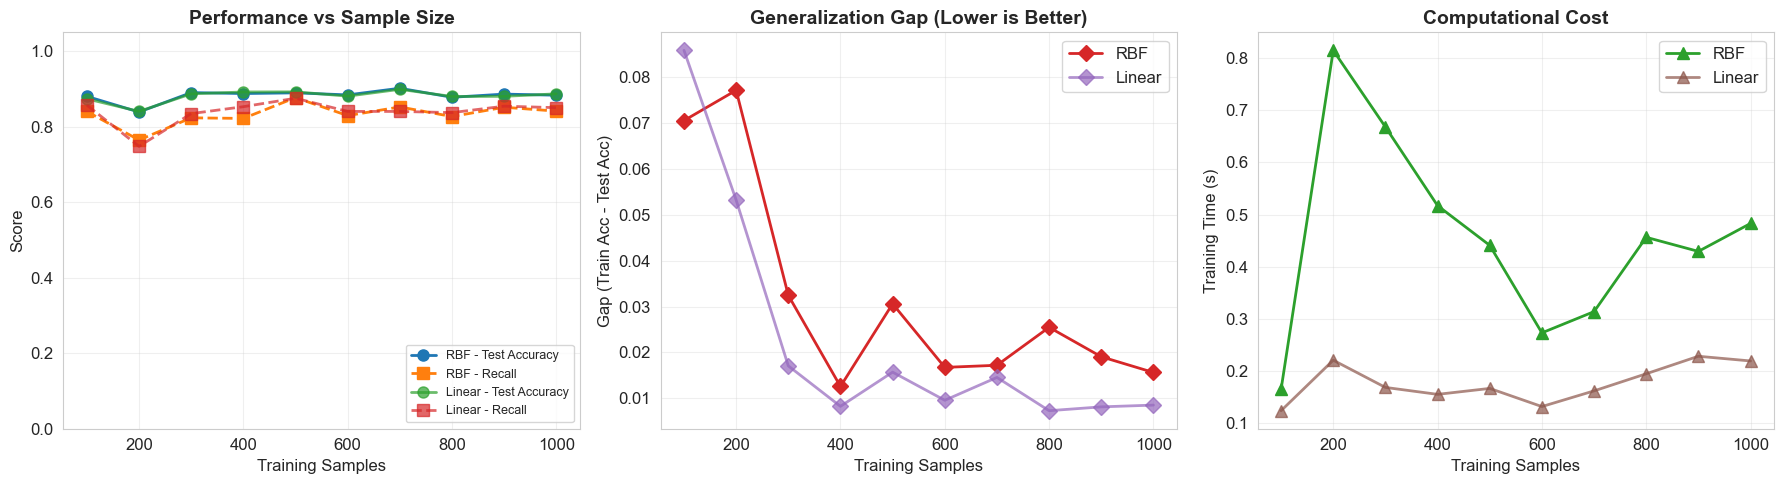


--- Plotting: Effect of PCA Components ---


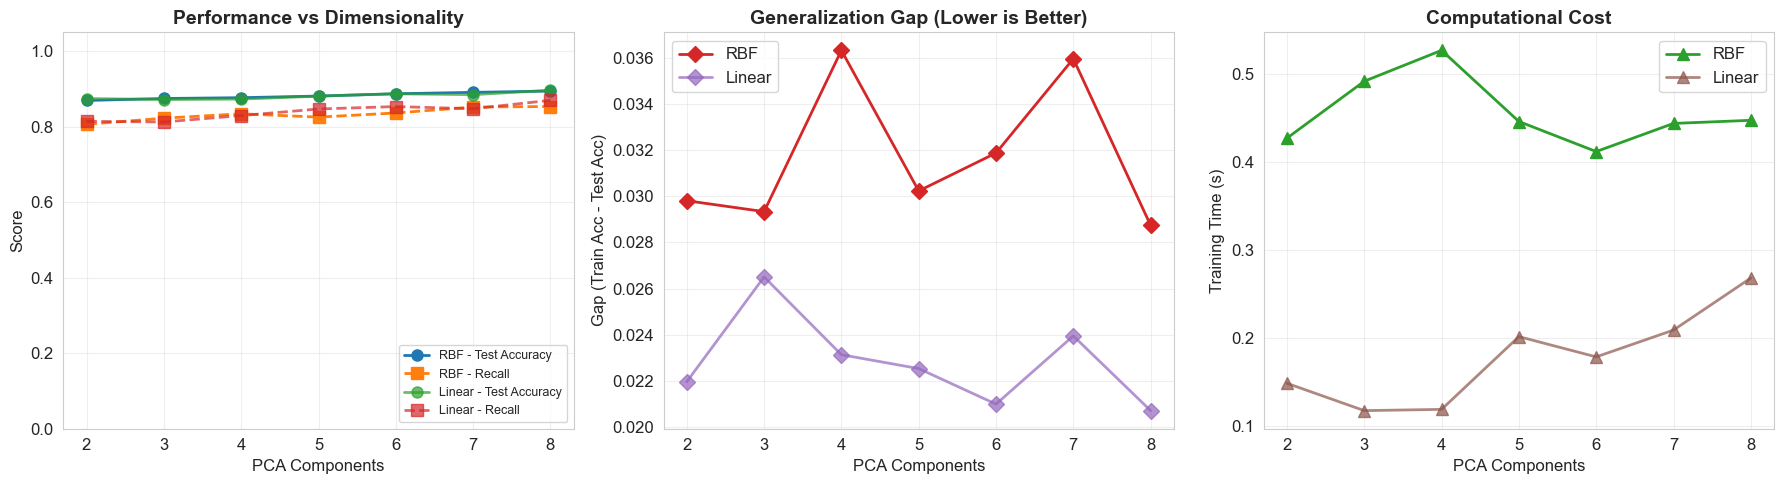


--- Plotting: Performance Heatmaps ---


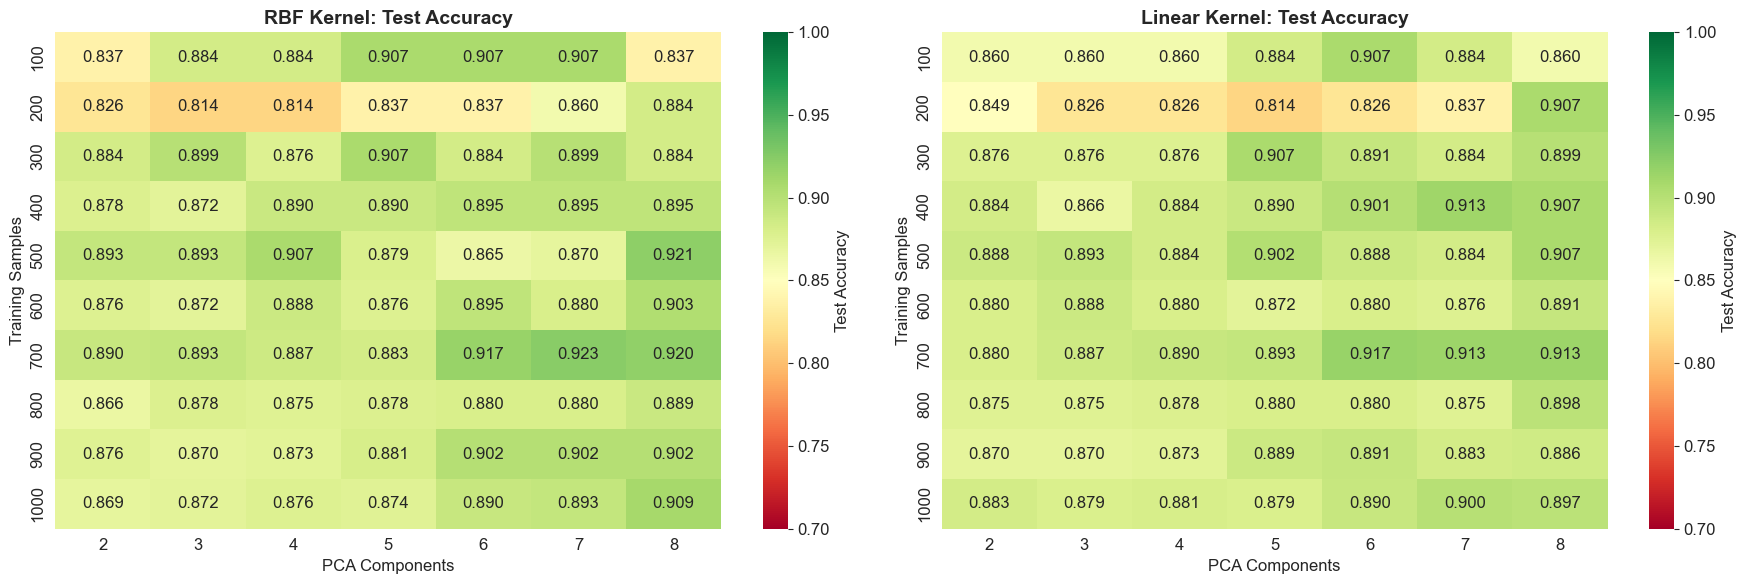

In [42]:
# Generate the standard visualizations
plot_classical_svm_analysis(results_df)

##### FULL DATASET PERFORMANCE EXPERIMENTS (PCA)


In [43]:
# ================================================================================
# FULL DATASET EXPERIMENTS
# ================================================================================
print("\n" + "="*80)
print("STARTING FULL DATASET EXPERIMENTS (BASELINE ESTABLISHMENT)")
print("="*80)

# Define parameter ranges for full dataset experiments
n_components_range_full = [2, 3, 4, 5, 6, 7, 8]
kernels_full = ['linear', 'rbf']

full_dataset_results = []
exp_count = 1

for n_comp in n_components_range_full:
    for kernel in kernels_full:
        print(f"\n" + "="*80)
        print(f"FULL DATASET EXPERIMENT {exp_count}/{len(n_components_range_full) * len(kernels_full)}: {n_comp} components, {kernel} kernel")
        print("="*80)
        
        # Data preparation (full dataset)
        X_full = df.drop('label', axis=1)
        y_full = df['label']
        
        # Stratified train-test split for the full dataset
        X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
            X_full, y_full, test_size=0.3, random_state=42, stratify=y_full
        )
        
        # Scaling
        scaler = StandardScaler()
        X_train_scaled_df_full = pd.DataFrame(scaler.fit_transform(X_train_full), columns=X_train_full.columns)
        X_test_scaled_df_full = pd.DataFrame(scaler.transform(X_test_full), columns=X_train_full.columns)
        
        # Correlation filtering
        THRESH = 0.9
        corr_matrix_train = X_train_scaled_df_full.corr().abs()
        upper_triangle = corr_matrix_train.where(
            np.triu(np.ones(corr_matrix_train.shape), k=1).astype(bool)
        )
        
        columns_to_drop = set()
        for column in upper_triangle.columns:
            high_corr_partners = upper_triangle.index[upper_triangle[column] > THRESH].tolist()
            if high_corr_partners:
                for partner in high_corr_partners:
                    corr_main = y_train_full.corr(X_train_scaled_df_full[column])
                    corr_partner = y_train_full.corr(X_train_scaled_df_full[partner])
                    if abs(corr_main) < abs(corr_partner):
                        columns_to_drop.add(column)
                    else:
                        columns_to_drop.add(partner)
        
        X_train_reduced = X_train_scaled_df_full.drop(columns=sorted(list(columns_to_drop)))
        X_test_reduced = X_test_scaled_df_full.drop(columns=sorted(list(columns_to_drop)))
        
        # PCA dimensionality reduction
        pca = PCA(n_components=n_comp, random_state=42)
        X_train_final = pca.fit_transform(X_train_reduced)
        X_test_final = pca.transform(X_test_reduced)
        
        explained_var = pca.explained_variance_ratio_.sum()
        print(f"  → PCA: {n_comp} components (Explained variance: {explained_var:.2%})")
        
        # Grid search
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        if kernel == 'rbf':
            param_grid = {
                'C': [0.001, 0.01, 0.1, 1, 10, 100],
                'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
            }
            svm_model = SVC(kernel='rbf', random_state=42)
        else:
            param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
            svm_model = SVC(kernel='linear', random_state=42)
        
        grid_search = GridSearchCV(
            svm_model, param_grid, cv=cv, scoring='accuracy', verbose=0, n_jobs=-1
        )
        
        start_train = time.time()
        grid_search.fit(X_train_final, y_train_full)
        train_time = time.time() - start_train
        
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        best_c = best_params['C']
        best_gamma = best_params.get('gamma', None)
        cv_score = grid_search.best_score_
        
        # Predictions
        y_train_pred = best_model.predict(X_train_final)
        y_test_pred = best_model.predict(X_test_final)
        
        # Metrics
        train_acc = accuracy_score(y_train_full, y_train_pred)
        test_acc = accuracy_score(y_test_full, y_test_pred)
        precision = precision_score(y_test_full, y_test_pred, zero_division=0)
        recall = recall_score(y_test_full, y_test_pred, zero_division=0)
        f1 = f1_score(y_test_full, y_test_pred, zero_division=0)
        gen_gap = abs(train_acc - test_acc)
        
        print(f"  → Train Accuracy: {train_acc:.4f}")
        print(f"  → Test Accuracy: {test_acc:.4f}")
        print(f"  → Precision: {precision:.4f}")
        print(f"  → Recall: {recall:.4f}")
        print(f"  → F1 Score: {f1:.4f}")
        print(f"  → Gen Gap: {gen_gap:.4f}")
        print(f"  → Best C: {best_c}")
        if best_gamma:
            print(f"  → Best Gamma: {best_gamma}")
        
        # Store results
        full_dataset_results.append({
            'experiment_id': f'Full_{n_comp}comp_{kernel}',
            'samples': len(df),
            'n_components': n_comp,
            'kernel': kernel,
            'best_c': best_c,
            'best_gamma': best_gamma,
            'cv_score': cv_score,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'gen_gap': gen_gap,
            'train_time': train_time,
            'explained_variance_ratio': explained_var
        })
        
        exp_count += 1

print("\n" + "="*80)
print("FULL DATASET EXPERIMENTS COMPLETE!")
print("="*80)

# Convert to DataFrame
full_results_df = pd.DataFrame(full_dataset_results)



STARTING FULL DATASET EXPERIMENTS (BASELINE ESTABLISHMENT)

FULL DATASET EXPERIMENT 1/14: 2 components, linear kernel
  → PCA: 2 components (Explained variance: 15.56%)
  → Train Accuracy: 0.8704
  → Test Accuracy: 0.8725
  → Precision: 0.8769
  → Recall: 0.7917
  → F1 Score: 0.8321
  → Gen Gap: 0.0021
  → Best C: 0.1

FULL DATASET EXPERIMENT 2/14: 2 components, rbf kernel
  → PCA: 2 components (Explained variance: 15.56%)
  → Train Accuracy: 0.8717
  → Test Accuracy: 0.8702
  → Precision: 0.8812
  → Recall: 0.7798
  → F1 Score: 0.8274
  → Gen Gap: 0.0016
  → Best C: 1
  → Best Gamma: 0.01

FULL DATASET EXPERIMENT 3/14: 3 components, linear kernel
  → PCA: 3 components (Explained variance: 19.23%)
  → Train Accuracy: 0.8728
  → Test Accuracy: 0.8733
  → Precision: 0.8789
  → Recall: 0.7917
  → F1 Score: 0.8330
  → Gen Gap: 0.0006
  → Best C: 1

FULL DATASET EXPERIMENT 4/14: 3 components, rbf kernel
  → PCA: 3 components (Explained variance: 19.23%)
  → Train Accuracy: 0.8751
  → Test 

In [44]:
# ================================================================================
# EXTRACT BEST FULL DATASET CONFIGURATIONS
# ================================================================================

# Separate full dataset results by kernel
full_rbf = full_results_df[full_results_df['kernel'] == 'rbf']
full_linear = full_results_df[full_results_df['kernel'] == 'linear']

# Find best configurations
best_full_rbf = full_rbf.loc[full_rbf['test_acc'].idxmax()]
best_full_linear = full_linear.loc[full_linear['test_acc'].idxmax()]

print("\n" + "="*80)
print("BEST FULL DATASET CONFIGURATIONS")
print("="*80)

print(f"\nBest Full RBF:")
print(f"  → Experiment ID: {best_full_rbf['experiment_id']}")
print(f"  → Samples: {int(best_full_rbf['samples'])}")
print(f"  → Components: {int(best_full_rbf['n_components'])}")
print(f"  → Train Accuracy: {best_full_rbf['train_acc']:.4f}")
print(f"  → Test Accuracy: {best_full_rbf['test_acc']:.4f}")
print(f"  → Precision: {best_full_rbf['precision']:.4f}")
print(f"  → Recall: {best_full_rbf['recall']:.4f}")
print(f"  → F1 Score: {best_full_rbf['f1_score']:.4f}")
print(f"  → Gen Gap: {best_full_rbf['gen_gap']:.4f}")
print(f"  → Best C: {best_full_rbf['best_c']}")
print(f"  → Best Gamma: {best_full_rbf['best_gamma']}")

print(f"\nBest Full Linear:")
print(f"  → Experiment ID: {best_full_linear['experiment_id']}")
print(f"  → Samples: {int(best_full_linear['samples'])}")
print(f"  → Components: {int(best_full_linear['n_components'])}")
print(f"  → Train Accuracy: {best_full_linear['train_acc']:.4f}")
print(f"  → Test Accuracy: {best_full_linear['test_acc']:.4f}")
print(f"  → Precision: {best_full_linear['precision']:.4f}")
print(f"  → Recall: {best_full_linear['recall']:.4f}")
print(f"  → F1 Score: {best_full_linear['f1_score']:.4f}")
print(f"  → Gen Gap: {best_full_linear['gen_gap']:.4f}")
print(f"  → Best C: {best_full_linear['best_c']}")

print("\n" + "="*80)



BEST FULL DATASET CONFIGURATIONS

Best Full RBF:
  → Experiment ID: Full_8comp_rbf
  → Samples: 4210
  → Components: 8
  → Train Accuracy: 0.9365
  → Test Accuracy: 0.9177
  → Precision: 0.9098
  → Recall: 0.8810
  → F1 Score: 0.8952
  → Gen Gap: 0.0189
  → Best C: 10.0
  → Best Gamma: auto

Best Full Linear:
  → Experiment ID: Full_8comp_linear
  → Samples: 4210
  → Components: 8
  → Train Accuracy: 0.8877
  → Test Accuracy: 0.8884
  → Precision: 0.8972
  → Recall: 0.8135
  → F1 Score: 0.8533
  → Gen Gap: 0.0007
  → Best C: 0.1



In [45]:
# ================================================================================
# SUBSET vs FULL DATASET COMPARISON
# ================================================================================

print("\n" + "="*80)
print("SUBSET vs FULL DATASET COMPARISON")
print("="*80)

# Separate subset results by kernel (from results_df)
rbf_data = results_df[results_df['kernel'] == 'rbf']
linear_data = results_df[results_df['kernel'] == 'linear']

# Best from each subset
best_subset_rbf = rbf_data.loc[rbf_data['test_accuracy'].idxmax()]
best_subset_linear = linear_data.loc[linear_data['test_accuracy'].idxmax()]

# ==========================================
# COMPARISON TABLE
# ==========================================

comparison_data = {
    'Configuration': ['Subset (Best)', 'Full Dataset', 'Difference'],
    'RBF Accuracy': [
        f"{best_subset_rbf['test_accuracy']:.4f}",
        f"{best_full_rbf['test_acc']:.4f}",
        f"{(best_full_rbf['test_acc'] - best_subset_rbf['test_accuracy']):.4f}"
    ],
    'RBF Recall': [
        f"{best_subset_rbf['recall']:.4f}",
        f"{best_full_rbf['recall']:.4f}",
        f"{(best_full_rbf['recall'] - best_subset_rbf['recall']):.4f}"
    ],
    'RBF Components': [
        int(best_subset_rbf['n_components']),
        int(best_full_rbf['n_components']),
        int(best_full_rbf['n_components'] - best_subset_rbf['n_components'])
    ],
    'RBF Samples': [
        int(best_subset_rbf['samples']),
        int(best_full_rbf['samples']),
        f"{((best_full_rbf['samples'] - best_subset_rbf['samples']) / best_full_rbf['samples'] * 100):.1f}% more"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# ==========================================
# EFFICIENCY ANALYSIS
# ==========================================

print("\n" + "="*80)
print("EFFICIENCY ANALYSIS (RBF Kernel)")
print("="*80)

efficiency = (best_subset_rbf['test_accuracy'] / best_full_rbf['test_acc']) * 100
sample_reduction = (1 - best_subset_rbf['samples'] / best_full_rbf['samples']) * 100

print(f"\nSubset Configuration:")
print(f"  → Samples: {int(best_subset_rbf['samples'])}")
print(f"  → Components: {int(best_subset_rbf['n_components'])}")
print(f"  → Train Accuracy: {best_subset_rbf['train_accuracy']:.4f}")
print(f"  → Test Accuracy: {best_subset_rbf['test_accuracy']:.4f}")
print(f"  → Precision: {best_subset_rbf['precision']:.4f}")
print(f"  → Recall: {best_subset_rbf['recall']:.4f}")
print(f"  → F1 Score: {best_subset_rbf['f1_score']:.4f}")
print(f"  → Gen Gap: {best_subset_rbf['generalization_gap']:.4f}")
print(f"  → Best C: {best_subset_rbf['best_C']}")

print(f"\nFull Dataset Configuration:")
print(f"  → Samples: {int(best_full_rbf['samples'])}")
print(f"  → Components: {int(best_full_rbf['n_components'])}")
print(f"  → Train Accuracy: {best_full_rbf['train_acc']:.4f}")
print(f"  → Test Accuracy: {best_full_rbf['test_acc']:.4f}")
print(f"  → Precision: {best_full_rbf['precision']:.4f}")
print(f"  → Recall: {best_full_rbf['recall']:.4f}")
print(f"  → F1 Score: {best_full_rbf['f1_score']:.4f}")
print(f"  → Gen Gap: {best_full_rbf['gen_gap']:.4f}")
print(f"  → Best C: {best_full_rbf['best_c']}")

print(f"\nPerformance Metrics:")
print(f"  → Subset achieves {efficiency:.2f}% of full dataset accuracy")
print(f"  → Uses {sample_reduction:.1f}% fewer training samples")
print(f"  → Accuracy gap: {(best_full_rbf['test_acc'] - best_subset_rbf['test_accuracy'])*100:.2f}%")

if efficiency >= 98:
    print(f"  EXCELLENT: Subset performance is ≥98% of full dataset")
elif efficiency >= 95:
    print(f"  GOOD: Subset performance is ≥95% of full dataset")
elif efficiency >= 90:
    print(f"  ACCEPTABLE: Subset performance is ≥90% of full dataset")
else:
    print(f"  POOR: Subset significantly underperforms full dataset")

print("\n" + "="*80)



SUBSET vs FULL DATASET COMPARISON

Configuration RBF Accuracy RBF Recall  RBF Components RBF Samples
Subset (Best)       0.9233     0.8833               7         700
 Full Dataset       0.9177     0.8810               8        4210
   Difference      -0.0057    -0.0024               1  83.4% more

EFFICIENCY ANALYSIS (RBF Kernel)

Subset Configuration:
  → Samples: 700
  → Components: 7
  → Train Accuracy: 0.9057
  → Test Accuracy: 0.9233
  → Precision: 0.9217
  → Recall: 0.8833
  → F1 Score: 0.9021
  → Gen Gap: 0.0176
  → Best C: 100.0

Full Dataset Configuration:
  → Samples: 4210
  → Components: 8
  → Train Accuracy: 0.9365
  → Test Accuracy: 0.9177
  → Precision: 0.9098
  → Recall: 0.8810
  → F1 Score: 0.8952
  → Gen Gap: 0.0189
  → Best C: 10.0

Performance Metrics:
  → Subset achieves 100.62% of full dataset accuracy
  → Uses 83.4% fewer training samples
  → Accuracy gap: -0.57%
  EXCELLENT: Subset performance is ≥98% of full dataset



In [46]:
# ================================================================================
# SAVE COMBINED RESULTS TO CSV
# ================================================================================

# Save full dataset results
full_results_df.to_csv('classical_svm_pca_full_results.csv', index=False)
print("Full dataset results saved to 'classical_svm_pca_full_results.csv'")

# Combine subset and full dataset results
# Need to align column names between results_df and full_results_df
# results_df uses: test_accuracy, train_accuracy, generalization_gap, training_time
# full_results_df uses: test_acc, train_acc, gen_gap, train_time

# Rename columns in results_df to match full_results_df
results_df_renamed = results_df.rename(columns={
    'test_accuracy': 'test_acc',
    'train_accuracy': 'train_acc',
    'generalization_gap': 'gen_gap',
    'training_time': 'train_time'
})

# Combine
combined_results_df = pd.concat([results_df_renamed, full_results_df], ignore_index=True)
combined_results_df.to_csv('classical_svm_pca_all_results.csv', index=False)
print("Combined results (subset + full) saved to 'classical_svm_pca_all_results.csv'")

print(f"\nTotal experiments: {len(combined_results_df)}")
print(f"  → Subset experiments: {len(results_df)}")
print(f"  → Full dataset experiments: {len(full_results_df)}")


Full dataset results saved to 'classical_svm_pca_full_results.csv'
Combined results (subset + full) saved to 'classical_svm_pca_all_results.csv'

Total experiments: 154
  → Subset experiments: 140
  → Full dataset experiments: 14


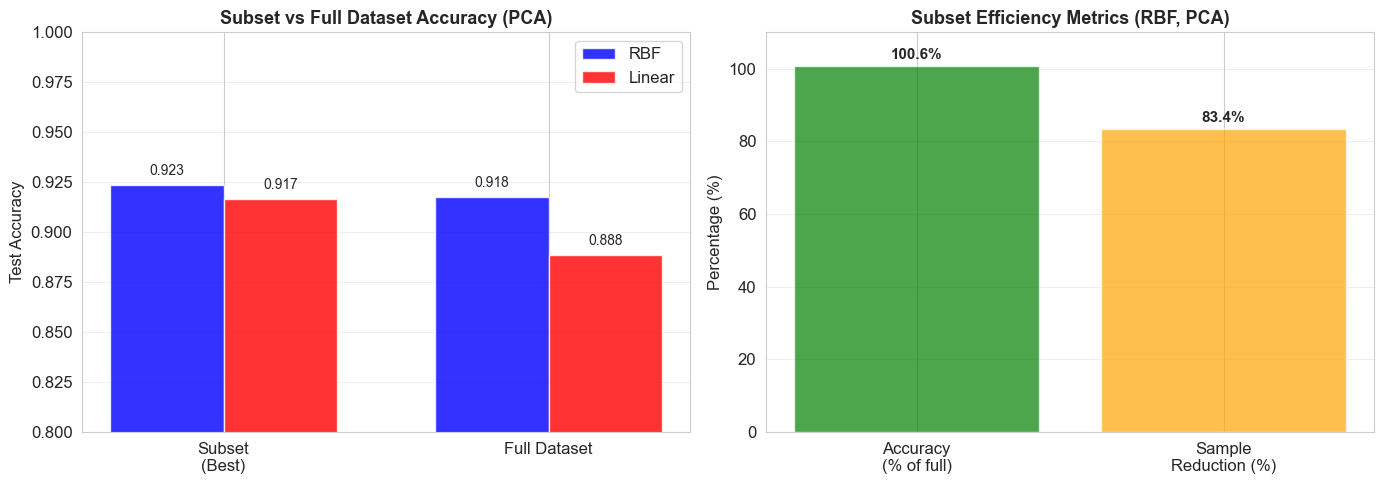

In [47]:
# ================================================================================
# VISUALIZATION: Subset vs Full Dataset
# ================================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy comparison
categories = ['Subset\n(Best)', 'Full Dataset']
rbf_accs = [best_subset_rbf['test_accuracy'], best_full_rbf['test_acc']]
linear_accs = [best_subset_linear['test_accuracy'], best_full_linear['test_acc']]

x = np.arange(len(categories))
width = 0.35

axes[0].bar(x - width/2, rbf_accs, width, label='RBF', color='blue', alpha=0.8)
axes[0].bar(x + width/2, linear_accs, width, label='Linear', color='red', alpha=0.8)
axes[0].set_ylabel('Test Accuracy', fontsize=12)
axes[0].set_title('Subset vs Full Dataset Accuracy (PCA)', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0.80, 1.0])

# Add value labels on bars
for i, (rbf, lin) in enumerate(zip(rbf_accs, linear_accs)):
    axes[0].text(i - width/2, rbf + 0.005, f'{rbf:.3f}', ha='center', fontsize=10)
    axes[0].text(i + width/2, lin + 0.005, f'{lin:.3f}', ha='center', fontsize=10)

# Plot 2: Efficiency visualization
metrics = ['Accuracy\n(% of full)', 'Sample\nReduction (%)']
values = [efficiency, sample_reduction]
colors = ['green', 'orange']

axes[1].bar(metrics, values, color=colors, alpha=0.7)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].set_title('Subset Efficiency Metrics (RBF, PCA)', fontsize=13, fontweight='bold')
axes[1].set_ylim([0, 110])
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(values):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()
